# Лабораторная работа 1

PyTorch, полносвязные сети, Word2Vec

Источник: materials/Лаб1.md, materials/Извлечение признаков из тектовых данных.md

## 1. Импорты и настройка окружения

PyTorch (torch, nn, optim, Dataset, DataLoader), scikit-learn (train_test_split, StandardScaler, метрики, PCA), matplotlib/seaborn для графиков, pandas/numpy для данных.

Настройка устройства: GPU если доступен, иначе CPU.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cpu


## 2. Предобработка датасетов для регрессии и классификации

Загрузка предобработанных датасетов из `processed/`:
- `neo_task_processed.csv` — классификация опасности астероидов (hazardous)
- `winequality_processed.csv` — регрессия качества вина (quality)

In [2]:
neo_df = pd.read_csv('processed/neo_task_processed.csv')
wine_df = pd.read_csv('processed/winequality_processed.csv')

neo_df = neo_df.drop('name', axis=1)

print(f'Neo task: {neo_df.shape}')
print(f'Wine quality: {wine_df.shape}')

Neo task: (90627, 7)
Wine quality: (5320, 13)


In [3]:
neo_features = neo_df.drop('hazardous', axis=1)
neo_target = neo_df['hazardous'].values

wine_features = wine_df.drop('quality', axis=1)
wine_target = wine_df['quality'].values

print(f'Neo features: {neo_features.shape}, target: {neo_target.shape}')
print(f'Wine features: {wine_features.shape}, target: {wine_target.shape}')

Neo features: (90627, 6), target: (90627,)
Wine features: (5320, 12), target: (5320,)


In [4]:
X_neo_train, X_neo_test, y_neo_train, y_neo_test = train_test_split(
    neo_features.values, neo_target, test_size=0.2, random_state=42, stratify=neo_target
)

X_wine_train, X_wine_test, y_wine_train, y_wine_test = train_test_split(
    wine_features.values, wine_target, test_size=0.2, random_state=42
)

print(f'Neo train: {X_neo_train.shape}, test: {X_neo_test.shape}')
print(f'Wine train: {X_wine_train.shape}, test: {X_wine_test.shape}')

Neo train: (72501, 6), test: (18126, 6)
Wine train: (4256, 12), test: (1064, 12)


In [5]:
scaler_neo = StandardScaler()
X_neo_train = scaler_neo.fit_transform(X_neo_train)
X_neo_test = scaler_neo.transform(X_neo_test)

scaler_wine = StandardScaler()
X_wine_train = scaler_wine.fit_transform(X_wine_train)
X_wine_test = scaler_wine.transform(X_wine_test)

print('Нормализация выполнена')

Нормализация выполнена


## 3. Dataset и DataLoader

Создание класса `TabularDataset` (наследник `torch.utils.data.Dataset`) для табличных данных. Источник: PyTorch документация.

Создание DataLoader для train/test выборок с batch_size=64 и shuffle=True для train.

In [6]:
class TabularDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.FloatTensor(features)
        self.targets = torch.LongTensor(targets) if targets.dtype == np.int64 else torch.FloatTensor(targets)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

In [7]:
neo_train_dataset = TabularDataset(X_neo_train, y_neo_train)
neo_test_dataset = TabularDataset(X_neo_test, y_neo_test)

wine_train_dataset = TabularDataset(X_wine_train, y_wine_train)
wine_test_dataset = TabularDataset(X_wine_test, y_wine_test)

print(f'Neo train dataset: {len(neo_train_dataset)}, test: {len(neo_test_dataset)}')
print(f'Wine train dataset: {len(wine_train_dataset)}, test: {len(wine_test_dataset)}')

Neo train dataset: 72501, test: 18126
Wine train dataset: 4256, test: 1064


In [8]:
batch_size = 64

neo_train_loader = DataLoader(neo_train_dataset, batch_size=batch_size, shuffle=True)
neo_test_loader = DataLoader(neo_test_dataset, batch_size=batch_size, shuffle=False)

wine_train_loader = DataLoader(wine_train_dataset, batch_size=batch_size, shuffle=True)
wine_test_loader = DataLoader(wine_test_dataset, batch_size=batch_size, shuffle=False)

print(f'Neo train batches: {len(neo_train_loader)}, test batches: {len(neo_test_loader)}')
print(f'Wine train batches: {len(wine_train_loader)}, test batches: {len(wine_test_loader)}')

Neo train batches: 1133, test batches: 284
Wine train batches: 67, test batches: 17


## 4. Полносвязные нейросети

`ClassificationNN` — полносвязная сеть для классификации с softmax на выходе (через CrossEntropyLoss). Источник: PyTorch nn.Module, nn.Linear, nn.ReLU.

`RegressionNN` — полносвязная сеть для регрессии с 1 нейроном на выходе. Источник: PyTorch nn.Module, nn.Linear.

Архитектура: вход → скрытый слой (128) → скрытый слой (64) → выход. Dropout 0.3 для регуляризации.

In [9]:
class ClassificationNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ClassificationNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [10]:
class RegressionNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(RegressionNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [11]:
input_size_neo = X_neo_train.shape[1]
input_size_wine = X_wine_train.shape[1]
hidden_size = 128

neo_model = ClassificationNN(input_size_neo, hidden_size, num_classes=2).to(device)
wine_model = RegressionNN(input_size_wine, hidden_size).to(device)

print(f'Neo model: {sum(p.numel() for p in neo_model.parameters())} параметров')
print(f'Wine model: {sum(p.numel() for p in wine_model.parameters())} параметров')

Neo model: 9282 параметров
Wine model: 9985 параметров


## 5. Обучение нейросетей

Функции обучения для классификации и регрессии. Источник: PyTorch tutorial — цикл обучения с forward → loss → backward → optimizer.step → optimizer.zero_grad.

- Классификация: CrossEntropyLoss, Adam optimizer, 30 эпох
- Регрессия: MSELoss, Adam optimizer, 50 эпох

Графики loss по эпохам для визуализации сходимости.

In [12]:
def train_classification(model, train_loader, criterion, optimizer, epochs, device):
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for features, targets in train_loader:
            features, targets = features.to(device), targets.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    return losses

In [13]:
def train_regression(model, train_loader, criterion, optimizer, epochs, device):
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for features, targets in train_loader:
            features, targets = features.to(device), targets.to(device)
            
            outputs = model(features).squeeze()
            loss = criterion(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')
    
    return losses

In [14]:
criterion_neo = nn.CrossEntropyLoss()
optimizer_neo = optim.Adam(neo_model.parameters(), lr=0.001)
epochs_neo = 20

print('Обучение классификационной модели (neo_task):')
neo_losses = train_classification(neo_model, neo_train_loader, criterion_neo, optimizer_neo, epochs_neo, device)

Обучение классификационной модели (neo_task):
Epoch [5/20], Loss: 0.1871
Epoch [10/20], Loss: 0.1851
Epoch [15/20], Loss: 0.1841
Epoch [20/20], Loss: 0.1831


In [15]:
criterion_wine = nn.MSELoss()
optimizer_wine = optim.Adam(wine_model.parameters(), lr=0.001)
epochs_wine = 30

print('Обучение регрессионной модели (winequality):')
wine_losses = train_regression(wine_model, wine_train_loader, criterion_wine, optimizer_wine, epochs_wine, device)

Обучение регрессионной модели (winequality):
Epoch [5/30], Loss: 1.6421
Epoch [10/30], Loss: 1.2315
Epoch [15/30], Loss: 1.1137
Epoch [20/30], Loss: 1.0740
Epoch [25/30], Loss: 1.0178
Epoch [30/30], Loss: 0.9448


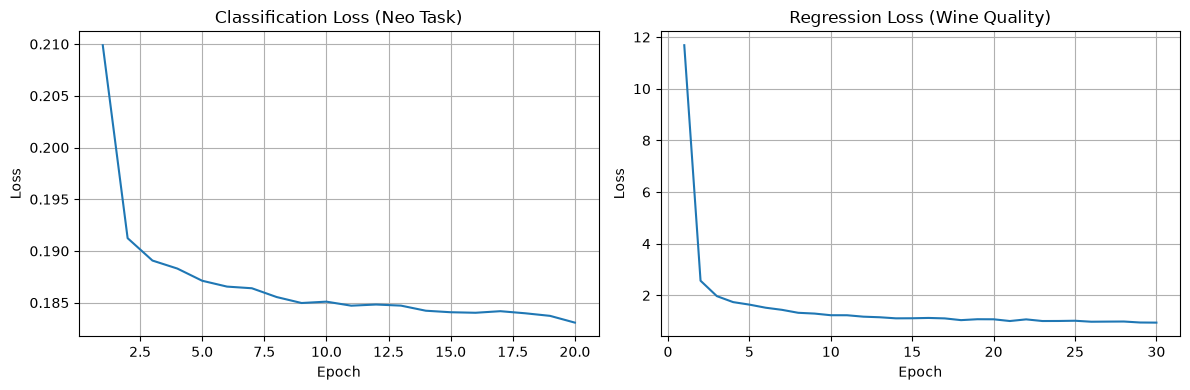

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, epochs_neo + 1), neo_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Classification Loss (Neo Task)')
axes[0].grid(True)

axes[1].plot(range(1, epochs_wine + 1), wine_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Regression Loss (Wine Quality)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Оценка качества

Классификация: accuracy, precision, recall, F1-score. Источник: scikit-learn метрики.

Регрессия: MSE, MAE, R2. Источник: scikit-learn метрики.

In [17]:
def evaluate_classification(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')
    
    return accuracy, precision, recall, f1

In [18]:
def evaluate_regression(model, test_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features).squeeze()
            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    
    return mse, mae, r2

In [19]:
neo_accuracy, neo_precision, neo_recall, neo_f1 = evaluate_classification(neo_model, neo_test_loader, device)

print('Метрики классификации (neo_task):')
print(f'Accuracy: {neo_accuracy:.4f}')
print(f'Precision: {neo_precision:.4f}')
print(f'Recall: {neo_recall:.4f}')
print(f'F1-score: {neo_f1:.4f}')

Метрики классификации (neo_task):
Accuracy: 0.9128
Precision: 0.8993
Recall: 0.9128
F1-score: 0.8867


In [20]:
wine_mse, wine_mae, wine_r2 = evaluate_regression(wine_model, wine_test_loader, device)

print('Метрики регрессии (winequality):')
print(f'MSE: {wine_mse:.4f}')
print(f'MAE: {wine_mae:.4f}')
print(f'R2: {wine_r2:.4f}')

Метрики регрессии (winequality):
MSE: 0.5399
MAE: 0.5728
R2: 0.2819


## 7. Предобработка текстового датасета (Petitions.csv)

Загрузка Petitions.csv, выбор текстового столбца, предобработка: нижний регистр, удаление спецсимволов, токенизация, построение словаря. Источник: Извлечение признаков из текстовых данных.

In [21]:
petitions_df = pd.read_csv('datasets/Petitions.csv')
print(f'Petitions shape: {petitions_df.shape}')
print(petitions_df.head())

Petitions shape: (59889, 3)
        id                               public_petition_text  reason_category
0  3168490                                     снег на дороге  Благоустройство
1  3219678                очистить кабельный киоск от рекламы  Благоустройство
2  2963920  Просим убрать все деревья и кустарники, которы...  Благоустройство
3  3374910  Неудовлетворительное состояние парадной - надп...   Содержание МКД
4  3336285                                           Граффити  Благоустройство


In [22]:
print('Столбцы датасета:', petitions_df.columns.tolist())

Столбцы датасета: ['id', 'public_petition_text', 'reason_category']


In [23]:
text_column = 'public_petition_text'
texts = petitions_df[text_column].astype(str).tolist()

print(f'Пример текста: {texts[0]}')
print(f'Всего текстов: {len(texts)}')

Пример текста: снег на дороге
Всего текстов: 59889


In [24]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Zа-яА-ЯёЁ\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [25]:
processed_texts = [preprocess_text(text) for text in texts]

tokenized_texts = [text.split() for text in processed_texts]

print(f'Пример токенизированного текста: {tokenized_texts[0]}')
print(f'Текстов после токенизации: {len(tokenized_texts)}')

Пример токенизированного текста: ['снег', 'на', 'дороге']
Текстов после токенизации: 59889


In [26]:
word_counts = Counter()
for tokens in tokenized_texts:
    word_counts.update(tokens)

print(f'Всего уникальных слов до фильтрации: {len(word_counts)}')
print(f'Пример слов: {list(word_counts.keys())[:10]}')

min_count = 1
vocab = {word: idx for idx, (word, count) in enumerate(word_counts.items()) if count >= min_count}
vocab_size = len(vocab)

print(f'Размер словаря: {vocab_size}')
print(f'Пример слов из словаря: {list(vocab.keys())[:10]}')

Всего уникальных слов до фильтрации: 43799
Пример слов: ['снег', 'на', 'дороге', 'очистить', 'кабельный', 'киоск', 'от', 'рекламы', 'просим', 'убрать']
Размер словаря: 43799
Пример слов из словаря: ['снег', 'на', 'дороге', 'очистить', 'кабельный', 'киоск', 'от', 'рекламы', 'просим', 'убрать']


In [27]:
indexed_texts = []
for tokens in tokenized_texts:
    indexed = [vocab[word] for word in tokens if word in vocab]
    if indexed:
        indexed_texts.append(indexed)

print(f'Количество текстов после фильтрации: {len(indexed_texts)}')
print(f'Пример индексированного текста: {indexed_texts[0] if indexed_texts else "нет"}')

Количество текстов после фильтрации: 59889
Пример индексированного текста: [0, 1, 2]


## 8. CBoW в PyTorch

Подготовка данных: контекст → целевое слово (window_size=2). Класс CBoWModel: Embedding → скрытый слой → CrossEntropyLoss. Источник: Извлечение признаков из текстовых данных, реализация CBoW в PyTorch.

In [28]:
def prepare_cbow_data(indexed_texts, window_size=2):
    data = []
    for text in indexed_texts:
        for i in range(len(text)):
            context_start = max(0, i - window_size)
            context_end = min(len(text), i + window_size + 1)
            context = [text[j] for j in range(context_start, context_end) if j != i]
            target = text[i]
            if len(context) > 0:
                data.append((context, target))
    return data

cbow_data = prepare_cbow_data(indexed_texts, window_size=2)
print(f'Количество пар CBoW: {len(cbow_data)}')

Количество пар CBoW: 770700


In [29]:
class CBoWDataset(Dataset):
    def __init__(self, data, vocab_size):
        self.data = data
        self.vocab_size = vocab_size
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        context, target = self.data[idx]
        context_tensor = torch.LongTensor(context)
        target_tensor = torch.LongTensor([target])
        return context_tensor, target_tensor.squeeze()

In [30]:
class CBoWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBoWModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(embedding_dim, vocab_size)
    
    def forward(self, context):
        embeds = self.embeddings(context)
        context_embed = embeds.mean(dim=1)
        output = self.fc(context_embed)
        return output

In [31]:
cbow_dataset = CBoWDataset(cbow_data, vocab_size)
cbow_loader = DataLoader(cbow_dataset, batch_size=16, shuffle=True, collate_fn=lambda batch: (torch.nn.utils.rnn.pad_sequence([x[0] for x in batch], batch_first=True), torch.stack([x[1] for x in batch])))

print(f'CBoW batches: {len(cbow_loader)}')

CBoW batches: 48169


In [ ]:
embedding_dim = 100
cbow_model = CBoWModel(vocab_size, embedding_dim).to(device)
criterion_cbow = nn.CrossEntropyLoss()
optimizer_cbow = optim.Adam(cbow_model.parameters(), lr=0.001)
epochs_cbow = 20

print('Обучение CBoW:')
cbow_losses = train_classification(cbow_model, cbow_loader, criterion_cbow, optimizer_cbow, epochs_cbow, device)

Обучение CBoW:


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs_cbow + 1), cbow_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CBoW Training Loss')
plt.grid(True)
plt.show()

## 9. SkipGram в PyTorch

Подготовка данных: целевое слово → контекст (window_size=2). Класс SkipGramModel: Embedding → скрытый слой → CrossEntropyLoss. Источник: Извлечение признаков из текстовых данных, реализация SkipGram в PyTorch.

In [ ]:
def prepare_skipgram_data(indexed_texts, window_size=2):
    data = []
    for text in indexed_texts:
        for i in range(len(text)):
            target = text[i]
            context_start = max(0, i - window_size)
            context_end = min(len(text), i + window_size + 1)
            context = [text[j] for j in range(context_start, context_end) if j != i]
            for context_word in context:
                data.append((target, context_word))
    return data

skipgram_data = prepare_skipgram_data(indexed_texts, window_size=2)
print(f'Количество пар SkipGram: {len(skipgram_data)}')

In [ ]:
class SkipGramDataset(Dataset):
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        target, context = self.data[idx]
        return torch.LongTensor([target]), torch.LongTensor([context])

In [ ]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(embedding_dim, vocab_size)
    
    def forward(self, target):
        embed = self.embeddings(target)
        embed = embed.squeeze()
        output = self.fc(embed)
        return output

In [ ]:
skipgram_dataset = SkipGramDataset(skipgram_data)
skipgram_loader = DataLoader(skipgram_dataset, batch_size=16, shuffle=True)

print(f'SkipGram batches: {len(skipgram_loader)}')

In [ ]:
skipgram_model = SkipGramModel(vocab_size, embedding_dim).to(device)
criterion_skipgram = nn.CrossEntropyLoss()
optimizer_skipgram = optim.Adam(skipgram_model.parameters(), lr=0.001)
epochs_skipgram = 20

print('Обучение SkipGram:')
skipgram_losses = train_classification(skipgram_model, skipgram_loader, criterion_skipgram, optimizer_skipgram, epochs_skipgram, device)

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs_skipgram + 1), skipgram_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SkipGram Training Loss')
plt.grid(True)
plt.show()

## 10. Контекстные эмбеддинги и PCA

Извлечение матрицы эмбеддингов из обученных моделей CBoW и SkipGram. PCA для уменьшения размерности до 2 компонент. Сохранение в TSV-файлы для визуализации в TensorBoard Projector. Источник: Извлечение признаков из текстовых данных.

In [ ]:
cbow_embeddings = cbow_model.embeddings.weight.data.cpu().numpy()
skipgram_embeddings = skipgram_model.embeddings.weight.data.cpu().numpy()

print(f'CBoW embeddings shape: {cbow_embeddings.shape}')
print(f'SkipGram embeddings shape: {skipgram_embeddings.shape}')

In [ ]:
pca = PCA(n_components=2)
cbow_pca = pca.fit_transform(cbow_embeddings)
skipgram_pca = pca.fit_transform(skipgram_embeddings)

print(f'CBoW PCA shape: {cbow_pca.shape}')
print(f'SkipGram PCA shape: {skipgram_pca.shape}')

In [ ]:
idx_to_word = {idx: word for word, idx in vocab.items()}

with open('processed/cbow_embeddings.tsv', 'w', encoding='utf-8') as f:
    for vec in cbow_pca:
        f.write('\t'.join(map(str, vec)) + '\n')

with open('processed/cbow_metadata.tsv', 'w', encoding='utf-8') as f:
    for idx in range(vocab_size):
        f.write(idx_to_word.get(idx, 'UNKNOWN') + '\n')

with open('processed/skipgram_embeddings.tsv', 'w', encoding='utf-8') as f:
    for vec in skipgram_pca:
        f.write('\t'.join(map(str, vec)) + '\n')

with open('processed/skipgram_metadata.tsv', 'w', encoding='utf-8') as f:
    for idx in range(vocab_size):
        f.write(idx_to_word.get(idx, 'UNKNOWN') + '\n')

print('TSV файлы сохранены')

## 11. Визуализация

Визуализация эмбеддингов в 2D пространстве PCA. Общая картина распределения слов и подписи для 50 наиболее частых слов. Источник: Извлечение признаков из текстовых данных, визуализация после PCA.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(cbow_pca[:, 0], cbow_pca[:, 1], alpha=0.5)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].set_title('CBoW Embeddings (PCA)')
axes[0].grid(True)

axes[1].scatter(skipgram_pca[:, 0], skipgram_pca[:, 1], alpha=0.5)
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].set_title('SkipGram Embeddings (PCA)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
top_words = 50
most_common_words = [word for word, _ in word_counts.most_common(top_words)]
most_common_indices = [vocab[word] for word in most_common_words if word in vocab]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx in most_common_indices:
    axes[0].scatter(cbow_pca[idx, 0], cbow_pca[idx, 1], alpha=0.7)
    axes[0].annotate(idx_to_word[idx], (cbow_pca[idx, 0], cbow_pca[idx, 1]), fontsize=8)
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].set_title(f'CBoW Embeddings - Top {top_words} Words')
axes[0].grid(True)

for idx in most_common_indices:
    axes[1].scatter(skipgram_pca[idx, 0], skipgram_pca[idx, 1], alpha=0.7)
    axes[1].annotate(idx_to_word[idx], (skipgram_pca[idx, 0], skipgram_pca[idx, 1]), fontsize=8)
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].set_title(f'SkipGram Embeddings - Top {top_words} Words')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Заключение

В данной лабораторной работе выполнены:
1. Загрузка и предобработка датасетов для регрессии (winequality) и классификации (neo_task)
2. Создание Dataset и DataLoader для табличных данных
3. Реализация полносвязных нейросетей для классификации и регрессии
4. Обучение моделей с использованием PyTorch (CrossEntropyLoss, MSELoss, Adam optimizer)
5. Оценка качества метриками (accuracy, precision, recall, F1 для классификации; MSE, MAE, R2 для регрессии)
6. Предобработка текстового датасета (Petitions.csv): токенизация, построение словаря
7. Собственная реализация CBoW в PyTorch
8. Собственная реализация SkipGram в PyTorch
9. Извлечение контекстных эмбеддингов и уменьшение размерности с помощью PCA
10. Сохранение эмбеддингов в TSV для визуализации в TensorBoard Projector
11. Визуализация эмбеддингов в 2D пространстве PCA